# Task 4 - Car-like (bicycle) robot

The state grows to `[x, y, theta, phi]` (phi = steering angle) and the control inputs are `[v, phidot]` (linear velocity and steering-angle velocity).

The URDF is `diffdrive_bicycle.urdf` (wheelbase L = 0.30 m, steering limited to +/-0.6 rad, steering rate to +/-2 rad/s).

A bike cannot rotate on the spot, so the simulation terminates on the goal *position* and accepts the heading the car naturally arrives with. Matching an exact final heading would require a parking-style maneuver, which is out of scope here.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import time
import pinocchio as pin
from pinocchio.visualize import MeshcatVisualizer
from meshcat.transformations import translation_matrix, rotation_matrix
from meshcat.geometry import Box, MeshPhongMaterial, Cylinder

### Visualization

In [2]:
# specify a path to the urdf files and meshes
urdf_model_path = "diffdrive_bicycle.urdf"   # <-- car-like (bicycle) robot
mesh_dir = ""

# load the robot using pinocchio
robot = pin.RobotWrapper.BuildFromURDF(urdf_model_path, mesh_dir)

# vizualize the robot using meshcat
viz = MeshcatVisualizer(robot.model, robot.collision_model, robot.visual_model)
viz.initViewer(loadModel=True)

def show_robot(x, y, theta, phi=0.0):
    # Configuration vector for this URDF = floating base (x, y, z + quaternion)
    # followed by the revolute steering-joint angle phi.
    quat = pin.Quaternion(pin.utils.rotate('z', theta)).coeffs()
    pos = np.array([x, y, 0.1])
    q = np.concatenate([pos, quat, [phi]])
    viz.display(q)


You can open the visualizer by visiting the following URL:
http://127.0.0.1:7002/static/


In [3]:
# Add a floor
# Add floor material
material_floor = MeshPhongMaterial()
material_floor.color = int(200) * 256**2 + int(200) * 256 + int(200)
# Add a floor
viz.viewer["/Floor"].set_object(
    Box([10, 10, 0.01]),
    material_floor
)
viz.viewer["/Floor"].set_transform(
    translation_matrix([0, 0, -0.005])
)

# Add obstacle material
material_obstacle = MeshPhongMaterial()
material_obstacle.color = int(100) * 256**2 + int(100) * 256 + int(100)

# Randomly generate 30 obstacle positions within a defined range
np.random.seed(6) #6
obstacle_positions = [
    np.array([np.random.uniform(-4.8, 4.8), np.random.uniform(-4.8, 4.8), 0.5])
    for _ in range(10)
]

# add cylinders for each obstacle
for i, pos in enumerate(obstacle_positions):
    viz.viewer[f"/Obstacle_{i}"].set_object(
        Cylinder(1, 0.2), material_obstacle
    )
    T_world_obs = translation_matrix(pos)
    T_world_obs[:3, :3] = pin.utils.rotate('x', np.pi / 2)
    viz.viewer[f"/Obstacle_{i}"].set_transform(
        T_world_obs
    )
for i, pos in enumerate(obstacle_positions[::2]):
    # Connect a wall (box) between the two obstacles
    wall_length = np.linalg.norm(obstacle_positions[2*i][:2] - obstacle_positions[2*i+1][:2])
    wall_width = 0.4
    wall_height = 1.0
    wall_material = MeshPhongMaterial()
    wall_material.color = int(100) * 256**2 + int(100) * 256 + int(100)

    wall_position = (obstacle_positions[2*i][:2] + obstacle_positions[2*i+1][:2]) / 2

    viz.viewer[f"/Wall_Obstacle_{i}"].set_object(
        Box([wall_length, wall_width, wall_height]), wall_material
    )
    # Set the wall rotation to align with the line between the two obstacles
    angle = np.arctan2(
        obstacle_positions[2*i+1][1] - obstacle_positions[2*i][1],
        obstacle_positions[2*i+1][0] - obstacle_positions[2*i][0]
    )
    viz.viewer[f"/Wall_Obstacle_{i}"].set_transform(
        translation_matrix([wall_position[0], wall_position[1], wall_height / 2]) @
        rotation_matrix(angle, [0, 0, 1])
    )

# Add walls around the floor
wall_thickness = 0.1
wall_height = 1.0

# Left wall
viz.viewer["/Wall_Left"].set_object(Box([wall_thickness, 10, wall_height]))
viz.viewer["/Wall_Left"].set_transform(
    translation_matrix([-5 - wall_thickness / 2, 0, wall_height / 2])
)

# Right wall
viz.viewer["/Wall_Right"].set_object(Box([wall_thickness, 10, wall_height]))
viz.viewer["/Wall_Right"].set_transform(
    translation_matrix([5 + wall_thickness / 2, 0, wall_height / 2])
)

# Front wall
viz.viewer["/Wall_Front"].set_object(Box([10, wall_thickness, wall_height]))
viz.viewer["/Wall_Front"].set_transform(
    translation_matrix([0, 5 + wall_thickness / 2, wall_height / 2])
)

# Back wall
viz.viewer["/Wall_Back"].set_object(Box([10, wall_thickness, wall_height]))
viz.viewer["/Wall_Back"].set_transform(
    translation_matrix([0, -5 - wall_thickness / 2, wall_height / 2])
)

# can you add a tower in each corner of the walls?
tower_height = 1.5
tower_radius = 0.3
tower_material = MeshPhongMaterial()
tower_material.color = int(100) * 256**2 + int(100) * 256 + int(100)

tower_positions = [
    np.array([-5 - wall_thickness / 2, 5 + wall_thickness / 2, tower_height / 2]),
    np.array([5 + wall_thickness / 2, 5 + wall_thickness / 2, tower_height / 2]),
    np.array([-5 - wall_thickness / 2, -5 - wall_thickness / 2, tower_height / 2]),
    np.array([5 + wall_thickness / 2, -5 - wall_thickness / 2, tower_height / 2])
]

for i, pos in enumerate(tower_positions):
    viz.viewer[f"/Tower_{i}"].set_object(
        Cylinder(tower_height, tower_radius), tower_material
    )
    T_world_tower = translation_matrix(pos)
    T_world_tower[:3, :3] = pin.utils.rotate('x', np.pi / 2)
    viz.viewer[f"/Tower_{i}"].set_transform(
        T_world_tower
    )

In [4]:
x, y, theta, phi = 0, 0, 0, 0
show_robot(x, y, theta, phi)


### Simulation

In [5]:
# --- Car-like (bicycle) robot ---
# State:    [x, y, theta, phi]   (phi = steering angle)
# Control:  [v, phidot]          (linear velocity, steering-angle velocity)
# Wheelbase L from the URDF: front wheel at x=+0.15, rear wheel at x=-0.15.
L = 0.30
PHI_MAX = 0.6   # steering-angle limit (URDF revolute limit = +/- 0.6 rad)

def discrete_dynamics(state, control_input, dt, model_mismatch=False):
    """
    Bicycle (car-like) kinematics, rear-axle reference point.

    state:   [x, y, theta, phi]
    control: [v, phidot]
    """
    x, y, theta, phi = state
    v, phidot = control_input

    if model_mismatch:
        # Small actuation disturbance on the control inputs. The std-devs must
        # stay consistent with the EKF's sigma_v / sigma_phidot so the filter's
        # process noise Q matches the disturbance that actually enters the system.
        v      += np.random.normal(0, 0.1)
        phidot += np.random.normal(0, 0.1)

    # Bicycle kinematics
    x     += v * np.cos(theta) * dt
    y     += v * np.sin(theta) * dt
    theta += (v / L) * np.tan(phi) * dt
    phi   += phidot * dt

    # Steering angle is physically limited; heading wraps to [-pi, pi].
    phi   = np.clip(phi, -PHI_MAX, PHI_MAX)
    theta = np.arctan2(np.sin(theta), np.cos(theta))

    return np.array([x, y, theta, phi])


In [6]:
def simulation(controller):
    dt = 0.01
    simulation_time = 5
    sensor_noise_stddev = 0.03

    x, y, theta, phi = 0.0, 0.0, 0.0, 0.0

    for t in np.arange(0, simulation_time, dt):
        z = np.array([x, y]) + np.random.normal(0, sensor_noise_stddev, 2)
        v, phidot = controller(x, y, theta, z)
        x, y, theta, phi = discrete_dynamics([x, y, theta, phi], [v, phidot], dt, model_mismatch=True)
        show_robot(x, y, theta, phi)
        time.sleep(dt)


In [7]:
def controller(x, y, theta, z):
    # demo: drive forward with a small constant steering rate (the car curves)
    return 1.0, 0.1


In [8]:
simulation(controller)

# 1.1 Local Planner
Optimization-based motion planner for the robot, ignoring obstacles

In [9]:
import casadi as ca
import numpy as np

def local_planner(start, goal, N=20, dt=0.2):
    """Bicycle local planner used as the PRM subroutine.

    Only the POSITION (x, y) is pinned at the two ends; heading and steering are
    left FREE. For a forward-only car this makes every short connection feasible
    and keeps the NLP easy and fast (the optimiser returns a straight, phi=0
    segment when that is cheapest). Pinning the heading at both ends -- as one
    would for the unicycle -- makes most short edges infeasible for the car and
    wastes solver iterations, which is why graph building was slow and empty.

    start, goal : array-like; only the first two entries (x, y) are used.
    Returns X (4 x N+1) = [x, y, theta, phi]  and  U (2 x N) = [v, phidot].
    """
    start = np.asarray(start, dtype=float)
    goal  = np.asarray(goal,  dtype=float)

    opti = ca.Opti()
    X = opti.variable(4, N + 1)   # [x, y, theta, phi]
    U = opti.variable(2, N)       # [v, phidot]

    cost = 0
    for k in range(N):
        cost += 1.0  * U[0, k]**2
        cost += 20.0 * U[1, k]**2
        if k < N - 1:
            cost += 10.0 * (U[1, k+1] - U[1, k])**2
    opti.minimize(cost)

    # Bicycle kinematics
    for k in range(N):
        opti.subject_to(X[0, k+1] == X[0, k] + U[0, k] * ca.cos(X[2, k]) * dt)
        opti.subject_to(X[1, k+1] == X[1, k] + U[0, k] * ca.sin(X[2, k]) * dt)
        opti.subject_to(X[2, k+1] == X[2, k] + (U[0, k] / L) * ca.tan(X[3, k]) * dt)
        opti.subject_to(X[3, k+1] == X[3, k] + U[1, k] * dt)

    # Only POSITION is constrained at the ends (heading & steering left free).
    opti.subject_to(X[0:2, 0] == start[0:2])
    opti.subject_to(X[0:2, N] == goal[0:2])

    # Input and steering-angle limits (from the URDF).
    opti.subject_to(opti.bounded(0.0,  U[0, :], 1.5))
    opti.subject_to(opti.bounded(-2.0, U[1, :], 2.0))
    opti.subject_to(opti.bounded(-PHI_MAX, X[3, :], PHI_MAX))

    # Initial guess: straight line at the right average speed, wheels straight.
    th0 = np.arctan2(goal[1] - start[1], goal[0] - start[0])
    d   = np.linalg.norm(goal[0:2] - start[0:2])
    opti.set_initial(X[0, :], np.linspace(start[0], goal[0], N + 1))
    opti.set_initial(X[1, :], np.linspace(start[1], goal[1], N + 1))
    opti.set_initial(X[2, :], th0)
    opti.set_initial(X[3, :], 0.0)
    opti.set_initial(U[0, :], d / (N * dt))
    opti.set_initial(U[1, :], 0.0)

    # Fast settings: low iteration cap + early acceptance, so a hopeless edge
    # gives up quickly instead of grinding to max_iter.
    opti.solver('ipopt', {'ipopt.print_level': 0, 'print_time': 0,
                          'ipopt.max_iter': 150,
                          'ipopt.acceptable_tol': 1e-4,
                          'ipopt.acceptable_iter': 5})
    try:
        sol = opti.solve()
        return sol.value(X), sol.value(U)
    except:
        return None, None


# 1.2 Collision Check
Python function checks if a solution found by the local planner is effectively collision-free

In [10]:
# Collision parameters
r_robot = 0.31
r_obstacle = 0.2
r_tower = 0.3
safety_margin = 0.08

# --- Footprint of the car body ---
# r_robot is the single enclosing circle (kept as a reference). The car body
# is a 0.5 x 0.1 box drawn centred on (x, y); a single 0.31 m circle wastes a
# lot of lateral space. We instead cover it with TWO smaller circles placed
# along the heading axis at +/- 0.125 m, each of radius ~0.15 m. This is far
# tighter laterally, so the car can thread narrower gaps.
body_offsets = [0.125, -0.125]   # longitudinal offsets from (x, y), along theta
r_body = 0.15                    # radius of each small circle

# Cylinders + Towers as circles
obstacles_2d = []
for pos in obstacle_positions:
    obstacles_2d.append((pos[:2], r_obstacle))
for pos in tower_positions:
    obstacles_2d.append((pos[:2], r_tower))

# Outer walls as line segments
walls = [
    (np.array([-5.0, -5.0]), np.array([-5.0,  5.0])),
    (np.array([ 5.0, -5.0]), np.array([ 5.0,  5.0])),
    (np.array([-5.0,  5.0]), np.array([ 5.0,  5.0])),
    (np.array([-5.0, -5.0]), np.array([ 5.0, -5.0])),
]

# Connecting walls between cylinders
connection_walls = []
for i in range(len(obstacle_positions) // 2):
    p1 = obstacle_positions[2*i][:2]
    p2 = obstacle_positions[2*i+1][:2]
    connection_walls.append((p1, p2))

# Helper function (calculating the distance between the robot and the wall)
def point_to_segment_distance(point, seg_start, seg_end):
    seg = seg_end - seg_start
    t = np.dot(point - seg_start, seg) / np.dot(seg, seg)
    t = np.clip(t, 0, 1)
    closest = seg_start + t * seg
    return np.linalg.norm(point - closest)

In [11]:
def collision_check(X_path):
    """Two-circle collision check for the car-like body.

    The robot is no longer a single big circle: at every configuration the
    0.5 x 0.1 body is represented by two circles of radius r_body, placed along
    the heading axis at the offsets in body_offsets. Each circle is tested
    against every obstacle. Returns True if the whole path is collision-free.

    X_path rows are [x, y, theta, (phi)]; row 2 (theta) is used to orient the
    two circles, so X_path must carry the heading (it does: 4 x N+1 for segments,
    and 3 x 1 for single-point sampling tests).
    """
    for k in range(X_path.shape[1]):
        x, y, theta = X_path[0, k], X_path[1, k], X_path[2, k]
        c, s = np.cos(theta), np.sin(theta)

        for offset in body_offsets:
            center = np.array([x + offset * c, y + offset * s])

            # Cylinders and towers
            for obs_pos, obs_radius in obstacles_2d:
                if np.linalg.norm(center - obs_pos) < r_body + obs_radius + safety_margin:
                    return False

            # Outer walls
            for wall_start, wall_end in walls:
                if point_to_segment_distance(center, wall_start, wall_end) < r_body + safety_margin:
                    return False

            # Connecting walls between cylinders
            for wall_start, wall_end in connection_walls:
                wall_width = 0.2  # half of the wall width (0.4 in the visualizer)
                if point_to_segment_distance(center, wall_start, wall_end) < r_body + wall_width + safety_margin:
                    return False

    return True


# 1.3 Global Planner
Probabalistic roadmap (PRM) algorithm with local planner as subroutine

In [12]:
import heapq

def astar(graph, start, goal, samples):
    """A* shortest-path search over the PRM graph.

    The heuristic is the straight-line Euclidean distance in (x, y) from a node
    to the goal node. Since the edge weights are themselves Euclidean distances
    between sampled positions, this heuristic never overestimates the true
    remaining cost (it is admissible), so A* returns the same optimal path as
    Dijkstra while expanding fewer nodes.
    """
    def heuristic(node):
        return np.linalg.norm(samples[node][:2] - samples[goal][:2])

    g_score = {node: float('inf') for node in graph}
    g_score[start] = 0.0
    previous = {node: None for node in graph}

    # priority queue ordered by f = g + h ; (f, g, node)
    queue = [(heuristic(start), 0.0, start)]
    visited = set()

    while queue:
        f_current, g_current, current = heapq.heappop(queue)
        if current == goal:
            break
        if current in visited:
            continue
        visited.add(current)

        for neighbor, weight in graph[current]:
            tentative_g = g_current + weight
            if tentative_g < g_score[neighbor]:
                g_score[neighbor] = tentative_g
                previous[neighbor] = current
                f_neighbor = tentative_g + heuristic(neighbor)
                heapq.heappush(queue, (f_neighbor, tentative_g, neighbor))

    path = []
    current = goal
    while current is not None:
        path.append(current)
        current = previous[current]
    path.reverse()

    return path if path and path[0] == start else None


def prm(start, goal, n_samples=100, max_connections=5):
    # Step 1: Generate random points
    samples = [start]
    
    while len(samples) < n_samples + 1:
        x = np.random.uniform(-4.8, 4.8)
        y = np.random.uniform(-4.8, 4.8)
        theta = np.random.uniform(-np.pi, np.pi)
        point = np.array([x, y, theta])
        test_path = np.array([[x], [y], [theta]])
        if collision_check(test_path):
            samples.append(point)
    
    samples.append(goal)
    goal_idx = len(samples) - 1

    # Step 2: Build graph
    graph = {i: [] for i in range(len(samples))}
    saved_paths = {}
    
    print(f"Building graph with {len(samples)} nodes...")
    
    for i in range(len(samples)):
        distances = []
        for j in range(len(samples)):
            if i == j:
                continue
            dist = np.linalg.norm(samples[i][:2] - samples[j][:2])
            distances.append((dist, j))
        
        distances.sort()
        max_dist = 4.0
        connections = 0
        
        for dist, j in distances:
            if connections >= max_connections:
                break
            if dist > max_dist:
                break
            try:
                dx = samples[j][0] - samples[i][0]
                dy = samples[j][1] - samples[i][1]
                theta_ij = np.arctan2(dy, dx)

                if i == 0:
                    theta_start = start[2]
                else:
                    theta_start = theta_ij

                if j == goal_idx:
                    theta_goal = goal[2]
                else:
                    theta_goal = theta_ij

                start_i = np.array([samples[i][0], samples[i][1], theta_start])
                goal_j  = np.array([samples[j][0], samples[j][1], theta_goal])

                X_path, U_path = local_planner(start_i, goal_j)
                
                if X_path is None:
                    continue
                
                # Detect looping
                path_length = np.sum(np.linalg.norm(np.diff(X_path[:2,:], axis=1), axis=0))
                direct_dist = np.linalg.norm(goal_j[:2] - start_i[:2])
                if path_length > 3.0 * direct_dist:
                    continue
                
                if collision_check(X_path):
                    graph[i].append((j, dist))
                    graph[j].append((i, dist))
                    if (i,j) not in saved_paths:
                        saved_paths[(i,j)] = (X_path, U_path)
                        saved_paths[(j,i)] = (X_path[:, ::-1], U_path[:, ::-1])
                    connections += 1
            except:
                continue

    # Step 3: Find shortest path
    print("Searching for shortest path...")
    path_indices = astar(graph, 0, goal_idx, samples)
    
    if path_indices is None:
        print("No path found!")
        return None, None, None
    
    print(f"Path found! {len(path_indices)} waypoints.")

    # Step 4: assemble the reference directly from the feasible, collision-checked
    # edge solves found during graph building. We deliberately do NOT re-solve the
    # segments with smoothed (turning) headings: for a forward-only car those turns
    # are usually infeasible on one short segment, so the re-solve only fails slowly.
    # The straight segments meet at corners which the tracking controller rounds.
    segments = []
    segments_U = []
    for k in range(len(path_indices) - 1):
        key = (path_indices[k], path_indices[k + 1])
        X_seg, U_seg = saved_paths[key]
        segments.append(X_seg)
        segments_U.append(U_seg)

    path = [samples[idx] for idx in path_indices]
    print("✅ Reference assembled from feasible segments.")
    return path, segments, segments_U


## PRM: entering START and GOAL points 
if ✅ Path continuous!, a path has been found, otherwise, run cell again

In [13]:
start = np.array([0.0, 0.0, 0.0])
goal  = np.array([4.0, -4.0, 1.0])

# Estimate arrival direction
dx = goal[0] - start[0]
dy = goal[1] - start[1]
theta_arrival = np.arctan2(dy, dx)
goal_adjusted = np.array([goal[0], goal[1], theta_arrival])

path, segments, segments_U = prm(start, goal_adjusted, n_samples=200, max_connections=10)

if path is None:
    print("No path found, run again!")
else:
    print(f"Path found with {len(path)} waypoints!")
    
    # Create X_ref and U_ref directly
    X_ref = np.hstack(segments)
    U_ref = np.hstack(segments_U)
    print(f"X_ref: {X_ref.shape[1]} steps")
    print(f"U_ref: {U_ref.shape[1]} steps")

Building graph with 202 nodes...

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Searching for shortest path...
Path found! 6 waypoints.
✅ Reference assembled from feasible segments.
Path found with 6 waypoints!
X_ref: 105 steps
U_ref: 100 steps


to visualize the found path:

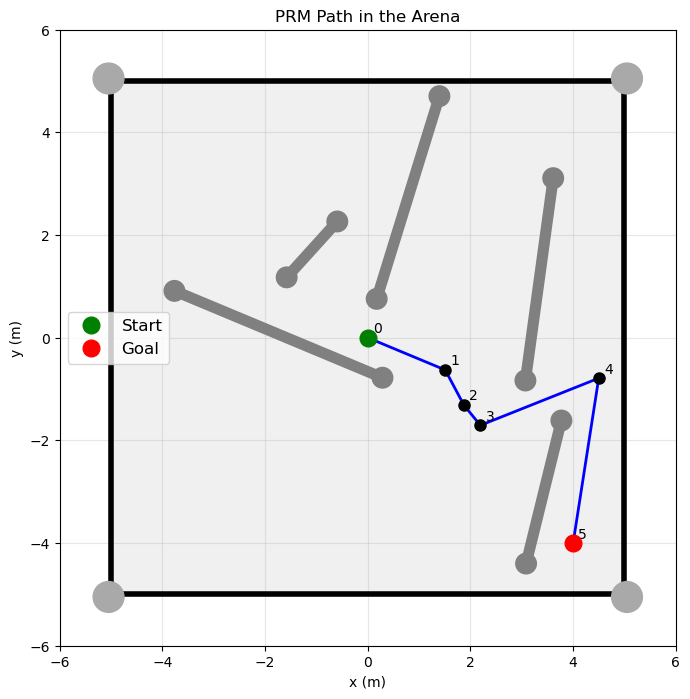

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Inner area
inner = patches.Rectangle((-5, -5), 10, 10,
                           linewidth=0, facecolor='#f0f0f0')
ax.add_patch(inner)

# Outer walls
for wall_start, wall_end in walls:
    ax.plot([wall_start[0], wall_end[0]], 
            [wall_start[1], wall_end[1]], 
            'k-', linewidth=4, zorder=3)

# Connecting walls between cylinders
for wall_start, wall_end in connection_walls:
    ax.plot([wall_start[0], wall_end[0]], 
            [wall_start[1], wall_end[1]], 
            color='gray', linewidth=8, zorder=3)

# Obstacle cylinders
for pos, r in obstacles_2d[:10]:
    circle = plt.Circle(pos, r, color='gray', zorder=4)
    ax.add_patch(circle)

# Corner towers
for pos, r in obstacles_2d[10:14]:
    circle = plt.Circle(pos, r, color='darkgray', zorder=4)
    ax.add_patch(circle)

# Path segments
for X_segment in segments:
    ax.plot(X_segment[0,:], X_segment[1,:], 'b-', linewidth=2, zorder=5)

# Waypoints
for i, p in enumerate(path):
    ax.plot(p[0], p[1], 'ko', markersize=8, zorder=6)
    ax.annotate(f'{i}', (p[0]+0.1, p[1]+0.1), fontsize=10, zorder=7)

# Start and Goal
ax.plot(path[0][0], path[0][1], 'go', markersize=12, label='Start', zorder=7)
ax.plot(path[-1][0], path[-1][1], 'ro', markersize=12, label='Goal', zorder=7)

ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)
ax.set_title('PRM Path in the Arena')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
plt.show()

# 2 Controller

In [15]:
class EKF:
    

    def __init__(self, sigma_v=0.1, sigma_phidot=0.1, sigma_gps=0.03):
        self.x = np.array([0.0, 0.0, 0.0, 0.0])           # [x, y, theta, phi]
        self.P = np.diag([0.1, 0.1, 0.1, 0.1])

        self.sigma_v = sigma_v
        self.sigma_phidot = sigma_phidot

        self.R = np.diag([sigma_gps**2, sigma_gps**2])    # GPS noise on (x, y)
        self.H = np.array([[1.0, 0.0, 0.0, 0.0],
                           [0.0, 1.0, 0.0, 0.0]])

    def predict(self, u, dt):
        v, phidot = u
        theta = self.x[2]
        phi   = self.x[3]

        # Nominal propagation
        self.x = discrete_dynamics(self.x, u, dt)

        # State Jacobian  F = df/dx
        F = np.array([
            [1.0, 0.0, -v * np.sin(theta) * dt, 0.0],
            [0.0, 1.0,  v * np.cos(theta) * dt, 0.0],
            [0.0, 0.0,  1.0, (v / L) * dt / np.cos(phi)**2],
            [0.0, 0.0,  0.0, 1.0]
        ])

        # Control Jacobian  B = df/du
        B = np.array([
            [np.cos(theta) * dt,    0.0],
            [np.sin(theta) * dt,    0.0],
            [np.tan(phi) / L * dt,  0.0],
            [0.0,                   dt ]
        ])

        M = np.diag([self.sigma_v**2, self.sigma_phidot**2])
        Q = B @ M @ B.T

        self.P = F @ self.P @ F.T + Q

    def update(self, z):
        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(4) - K @ self.H) @ self.P

        self.x[2] = np.arctan2(np.sin(self.x[2]), np.cos(self.x[2]))
        self.x[3] = np.clip(self.x[3], -PHI_MAX, PHI_MAX)

    def get_estimate(self):
        return self.x


In [16]:
def get_reference(x, y, lookahead_dist=0.5):
    """Pure-pursuit-style reference: pick the point on X_ref a fixed
    ARC-LENGTH ahead of the closest point. Indexing by distance (not by
    timestep) decouples the controller from the planner's dt, so it works
    even though the path was planned at dt=0.2 and simulated at dt=0.01."""
    N = X_ref.shape[1]
    i0 = getattr(get_reference, "idx", 0)

    # nearest point, searched forward only (monotonic progress)
    search_window = 80
    hi = min(i0 + search_window, N)
    seg = X_ref[:2, i0:hi]
    d2 = (seg[0] - x) ** 2 + (seg[1] - y) ** 2
    closest_idx = i0 + int(np.argmin(d2))
    get_reference.idx = max(i0, closest_idx)
    closest_idx = get_reference.idx

    # carrot a fixed arc-length ahead
    target_idx = closest_idx
    acc = 0.0
    while target_idx < N - 1 and acc < lookahead_dist:
        acc += np.linalg.norm(X_ref[:2, target_idx + 1] - X_ref[:2, target_idx])
        target_idx += 1

    ref = X_ref[:, target_idx]
    # heading reference: direction along the path at the carrot (robust, since
    # the planner left theta partly free on each segment)
    j = min(target_idx + 1, N - 1)
    dx = X_ref[0, j] - X_ref[0, target_idx]
    dy = X_ref[1, j] - X_ref[1, target_idx]
    if dx*dx + dy*dy > 1e-9:
        th_path = np.arctan2(dy, dx)
    else:
        th_path = ref[2]
    return ref, th_path

In [17]:
def controller(x, y, theta, phi, z, step):
    """Bicycle trajectory tracker.

    Feedforward v_ref is a fixed cruise speed (NOT taken from U_ref, which was
    computed at the planner's dt and is on the wrong scale). Heading reference
    comes from the path tangent. A minimum forward speed is enforced because a
    car cannot steer in place (w = (v/L) tan(phi) is zero when v = 0)."""
    k2 = 1.2     # lateral gain
    k3 = 2.5     # heading gain
    k_phi = 6.0  # steering-angle servo gain (inner loop)

    v_ref = 0.6  # cruise feedforward speed

    ref, th_ref = get_reference(x, y)
    x_ref, y_ref = ref[0], ref[1]

    e_x = x_ref - x
    e_y = y_ref - y
    e_theta = np.arctan2(np.sin(th_ref - theta), np.cos(th_ref - theta))

    # lateral error in the robot frame
    e_2 = -np.sin(theta) * e_x + np.cos(theta) * e_y

    # forward speed: cruise, with a guaranteed minimum so steering is effective
    v = np.clip(v_ref, 0.3, 1.5)

    # desired angular velocity -> desired steering angle (bicycle relation)
    w_des = k2 * e_2 + k3 * np.sin(e_theta)
    v_safe = max(v, 0.2)
    phi_des = np.clip(np.arctan(L * w_des / v_safe), -PHI_MAX, PHI_MAX)

    # steering-RATE command servos phi toward phi_des
    phidot = np.clip(k_phi * (phi_des - phi), -2.0, 2.0)

    return v, phidot

In [18]:
def simulation(controller, start, goal):
    dt = 0.01
    sensor_noise_stddev = 0.03

    x, y, theta = start
    phi = 0.0

    ekf = EKF()
    ekf.x = np.array([start[0], start[1], start[2], 0.0])
    get_reference.idx = 0

    max_steps = 6000      # 60 s of sim time
    pos_tol = 0.25
    step = 0

    # window-based stuck detector (per-step motion at dt=0.01 is tiny by design)
    check_every = 100
    last_check_pos = np.array([x, y])

    while step < max_steps:
        z = np.array([x, y]) + np.random.normal(0, sensor_noise_stddev, 2)

        ekf.update(z)
        x_est, y_est, theta_est, phi_est = ekf.get_estimate()

        dx, dy = goal[0] - x_est, goal[1] - y_est
        dist_to_goal = np.sqrt(dx**2 + dy**2)
        if dist_to_goal < pos_tol:
            print(f"\u2705 Goal reached! dist={dist_to_goal:.2f} m")
            break

        if dist_to_goal < 0.6:
            # final approach: aim at the goal point, slow down (no in-place turn)
            heading_to_goal = np.arctan2(dy, dx)
            e_h = np.arctan2(np.sin(heading_to_goal - theta_est),
                             np.cos(heading_to_goal - theta_est))
            v_cmd = np.clip(0.8 * dist_to_goal, 0.2, 0.6)
            w_des = 2.0 * e_h
            v_safe = max(v_cmd, 0.2)
            phi_des = np.clip(np.arctan(L * w_des / v_safe), -PHI_MAX, PHI_MAX)
            phidot_cmd = np.clip(6.0 * (phi_des - phi_est), -2.0, 2.0)
        else:
            v_cmd, phidot_cmd = controller(x_est, y_est, theta_est, phi_est, z, step)

        x, y, theta, phi = discrete_dynamics([x, y, theta, phi],
                                             [v_cmd, phidot_cmd], dt, model_mismatch=True)
        ekf.predict([v_cmd, phidot_cmd], dt)

        show_robot(x, y, theta, phi)
        time.sleep(dt)
        step += 1

        # windowed stuck check
        if step % check_every == 0:
            moved = np.linalg.norm(np.array([x, y]) - last_check_pos)
            if moved < 0.02:
                print(f"\u26a0\ufe0f Robot stuck at dist={dist_to_goal:.2f} m")
                break
            last_check_pos = np.array([x, y])

    if step >= max_steps:
        print("\u26a0\ufe0f Max steps reached.")

if "✅ Goal reached!", the simulation has ended successfully

In [20]:
simulation(controller, start, goal_adjusted)

✅ Goal reached! dist=0.25 m
